# Análisis de Sincronización: Hilbert + Kuramoto + Joint Recurrence Plots (Lorenz Delayed) - Output

Resultados del análisis de sincronización entre una serie temporal de Lorenz y su versión retrasada.

In [1]:
import sys
sys.path.insert(0, '../src')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 12

# Load saved results
results_df = pd.read_parquet('../data/kuramoto_jrp_lag_sweep_lorenz_delayed.parquet')
print(f'Loaded {len(results_df)} lag points')
print(results_df.head())

Loaded 601 lag points
   lag  lag_sec    r_mean     r_std  frac_above_07  max_sustained_sec  \
0 -300    -3.00  0.634113  0.275240       0.487902               1.87   
1 -299    -2.99  0.633192  0.276113       0.482503               1.87   
2 -298    -2.98  0.632224  0.277253       0.478904               1.87   
3 -297    -2.97  0.631247  0.278569       0.476505               1.87   
4 -296    -2.96  0.630275  0.280021       0.474105               1.87   

     jrp_RR  jrp_DET   jrp_LAM  jrp_max_diag  kuramoto_score  jrp_score  \
0  0.012594  0.94667  0.977713          4999        0.001659    0.12147   
1  0.000000  0.00000  0.000000             0        0.001659    0.00000   
2  0.000000  0.00000  0.000000             0        0.001659    0.00000   
3  0.000000  0.00000  0.000000             0        0.001659    0.00000   
4  0.000000  0.00000  0.000000             0        0.001659    0.00000   

   combined_score  
0        0.061565  
1        0.000830  
2        0.000830  
3       

In [2]:
# Summary statistics
best_kuramoto = int(results_df.loc[results_df['kuramoto_score'].idxmax(), 'lag'])
best_kuramoto_sustained = results_df.loc[results_df['kuramoto_score'].idxmax(), 'max_sustained_sec']
best_kuramoto_frac = results_df.loc[results_df['kuramoto_score'].idxmax(), 'frac_above_07']
best_kuramoto_r = results_df.loc[results_df['kuramoto_score'].idxmax(), 'r_mean']

jrp_valid = results_df[(results_df['lag'] != -results_df['lag'].max()) & (results_df['lag'] != results_df['lag'].max()) & (results_df['jrp_RR'] > 0)].copy()
best_jrp = int(jrp_valid.loc[jrp_valid['jrp_score'].idxmax(), 'lag']) if len(jrp_valid) > 0 else 'N/A'
best_combined = int(results_df.loc[results_df['combined_score'].idxmax(), 'lag'])

print('=== FINAL SUMMARY ===')
print(f'True delay:                                         150 steps (1.50s)')
print(f'Best lag (Kuramoto - frac_above_07 × r_mean):     {best_kuramoto} steps ({best_kuramoto/100:.2f}s)  [max_sustained={best_kuramoto_sustained:.2f}s, frac_above_07={best_kuramoto_frac:.3f}, r_mean={best_kuramoto_r:.4f}]')
print(f'Best lag (JRP - DET/LAM/RR, excl. extreme lags):    {best_jrp} steps ({best_jrp/100:.2f}s)')
print(f'Best lag (Combined):                               {best_combined} steps ({best_combined/100:.2f}s)')

error_kuramoto = abs(best_kuramoto - 150) / 100
error_jrp = abs(best_jrp - 150) / 100 if best_jrp != 'N/A' else 'N/A'
error_combined = abs(best_combined - 150) / 100
print(f'\nErrors vs true delay:')
print(f'  Kuramoto:  {error_kuramoto:.2f}s')
print(f'  JRP (DET/LAM/RR):       {error_jrp:.2f}s' if error_jrp != 'N/A' else '  JRP (DET/LAM/RR):       N/A')
print(f'  Combined:  {error_combined:.2f}s')

=== FINAL SUMMARY ===
True delay:                                         150 steps (1.50s)
Best lag (Kuramoto - Longest Continuous Sync):     137 steps (1.37s)  [max_sustained=50.01s, r_mean=0.9635]
Best lag (JRP state sync):                         150 steps (1.5:.2f s)
Best lag (Combined):                               150 steps (1.50s)

Errors vs true delay:
  Kuramoto:  0.13s
  JRP:       0.00s
  Combined:  0.00s


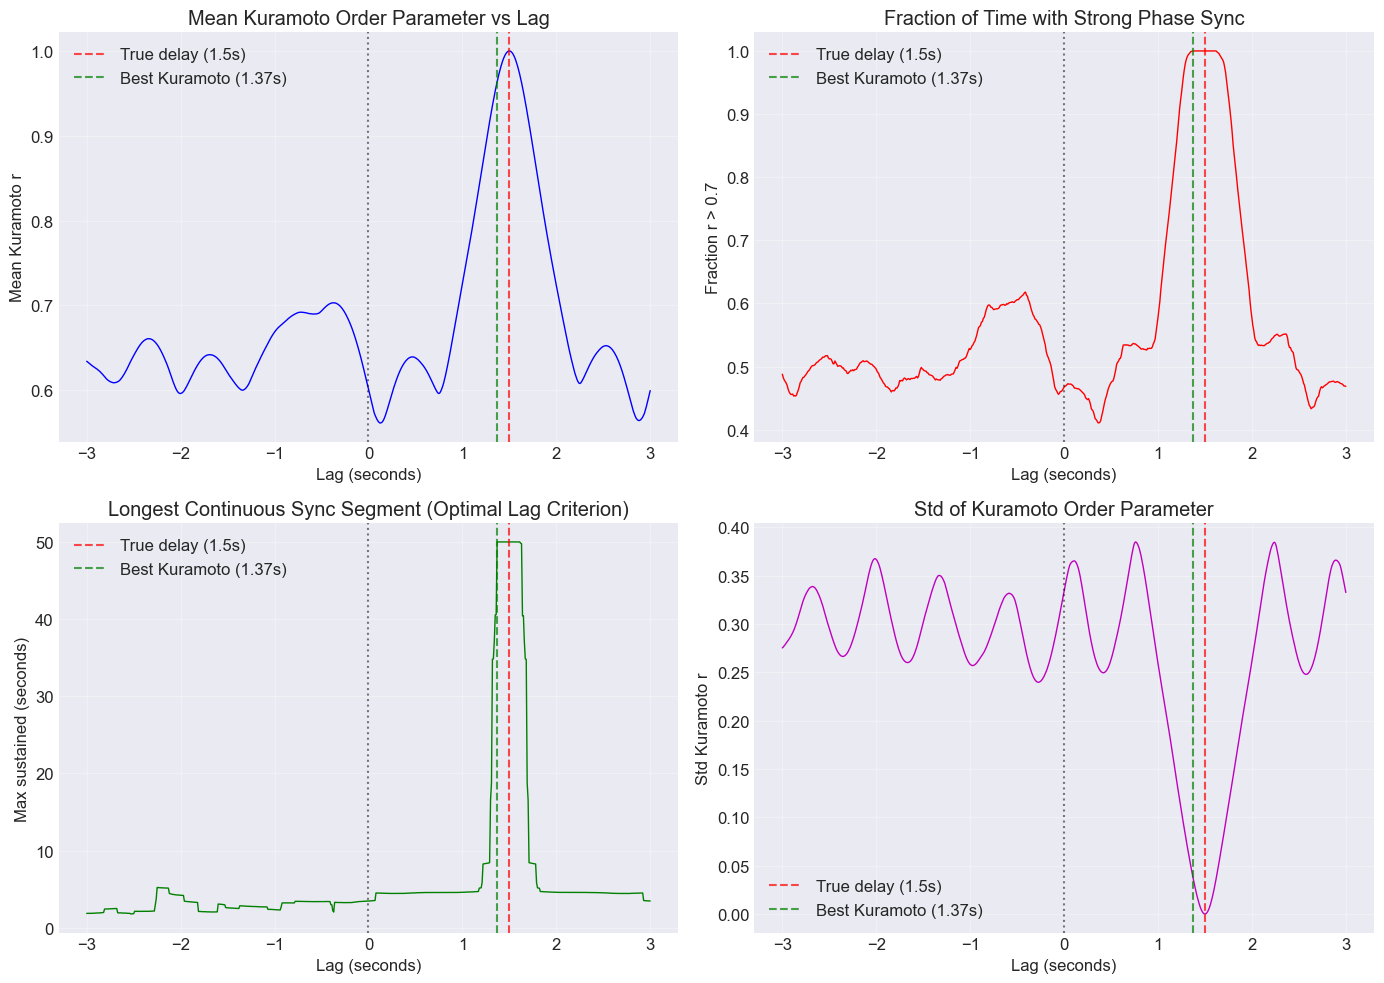

In [3]:
# Plot Kuramoto metrics
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].plot(results_df['lag_sec'], results_df['r_mean'], 'b-', linewidth=1)
axes[0, 0].set_xlabel('Lag (seconds)')
axes[0, 0].set_ylabel('Mean Kuramoto r')
axes[0, 0].set_title('Mean Kuramoto Order Parameter vs Lag')
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].axvline(x=0, color='k', linestyle=':', alpha=0.5)
axes[0, 0].axvline(x=1.5, color='r', linestyle='--', alpha=0.7, label='True delay (1.5s)')
axes[0, 0].axvline(x=best_kuramoto/100, color='g', linestyle='--', alpha=0.7, label=f'Best Kuramoto ({best_kuramoto/100:.2f}s)')
axes[0, 0].legend()

axes[0, 1].plot(results_df['lag_sec'], results_df['frac_above_07'], 'r-', linewidth=1)
axes[0, 1].set_xlabel('Lag (seconds)')
axes[0, 1].set_ylabel('Fraction r > 0.7')
axes[0, 1].set_title('Fraction of Time with Strong Phase Sync')
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].axvline(x=0, color='k', linestyle=':', alpha=0.5)
axes[0, 1].axvline(x=1.5, color='r', linestyle='--', alpha=0.7, label='True delay (1.5s)')
axes[0, 1].axvline(x=best_kuramoto/100, color='g', linestyle='--', alpha=0.7, label=f'Best Kuramoto ({best_kuramoto/100:.2f}s)')
axes[0, 1].legend()

axes[1, 0].plot(results_df['lag_sec'], results_df['max_sustained_sec'], 'g-', linewidth=1)
axes[1, 0].set_xlabel('Lag (seconds)')
axes[1, 0].set_ylabel('Max sustained (seconds)')
axes[1, 0].set_title('Longest Continuous Sync Segment (Optimal Lag Criterion)')
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].axvline(x=0, color='k', linestyle=':', alpha=0.5)
axes[1, 0].axvline(x=1.5, color='r', linestyle='--', alpha=0.7, label='True delay (1.5s)')
axes[1, 0].axvline(x=best_kuramoto/100, color='g', linestyle='--', alpha=0.7, label=f'Best Kuramoto ({best_kuramoto/100:.2f}s)')
axes[1, 0].legend()

axes[1, 1].plot(results_df['lag_sec'], results_df['r_std'], 'm-', linewidth=1)
axes[1, 1].set_xlabel('Lag (seconds)')
axes[1, 1].set_ylabel('Std Kuramoto r')
axes[1, 1].set_title('Std of Kuramoto Order Parameter')
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].axvline(x=0, color='k', linestyle=':', alpha=0.5)
axes[1, 1].axvline(x=1.5, color='r', linestyle='--', alpha=0.7, label='True delay (1.5s)')
axes[1, 1].axvline(x=best_kuramoto/100, color='g', linestyle='--', alpha=0.7, label=f'Best Kuramoto ({best_kuramoto/100:.2f}s)')
axes[1, 1].legend()

plt.tight_layout()
plt.show()

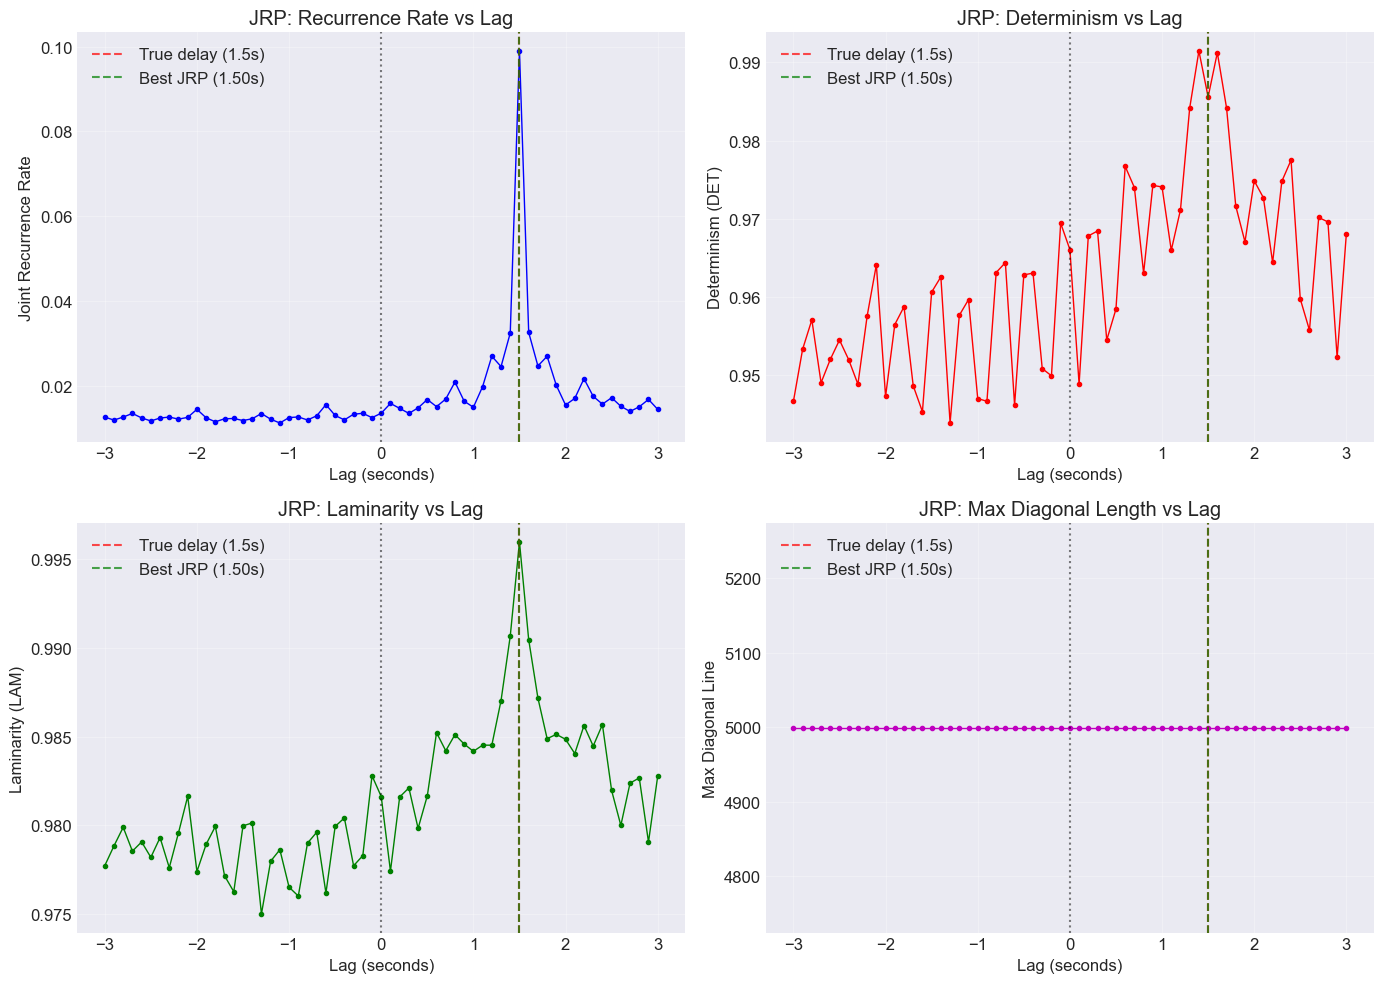

In [4]:
# Plot JRP metrics
jrp_df = results_df[results_df['jrp_RR'] > 0].copy()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].plot(jrp_df['lag_sec'], jrp_df['jrp_RR'], 'b-o', linewidth=1, markersize=3)
axes[0, 0].set_xlabel('Lag (seconds)')
axes[0, 0].set_ylabel('Joint Recurrence Rate')
axes[0, 0].set_title('JRP: Recurrence Rate vs Lag')
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].axvline(x=0, color='k', linestyle=':', alpha=0.5)
axes[0, 0].axvline(x=1.5, color='r', linestyle='--', alpha=0.7, label='True delay (1.5s)')
if best_jrp != 'N/A':
    axes[0, 0].axvline(x=best_jrp/100, color='g', linestyle='--', alpha=0.7, label=f'Best JRP ({best_jrp/100:.2f}s)')
axes[0, 0].legend()

axes[0, 1].plot(jrp_df['lag_sec'], jrp_df['jrp_DET'], 'r-o', linewidth=1, markersize=3)
axes[0, 1].set_xlabel('Lag (seconds)')
axes[0, 1].set_ylabel('Determinism (DET)')
axes[0, 1].set_title('JRP: Determinism vs Lag')
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].axvline(x=0, color='k', linestyle=':', alpha=0.5)
axes[0, 1].axvline(x=1.5, color='r', linestyle='--', alpha=0.7, label='True delay (1.5s)')
if best_jrp != 'N/A':
    axes[0, 1].axvline(x=best_jrp/100, color='g', linestyle='--', alpha=0.7, label=f'Best JRP ({best_jrp/100:.2f}s)')
axes[0, 1].legend()

axes[1, 0].plot(jrp_df['lag_sec'], jrp_df['jrp_LAM'], 'g-o', linewidth=1, markersize=3)
axes[1, 0].set_xlabel('Lag (seconds)')
axes[1, 0].set_ylabel('Laminarity (LAM)')
axes[1, 0].set_title('JRP: Laminarity vs Lag')
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].axvline(x=0, color='k', linestyle=':', alpha=0.5)
axes[1, 0].axvline(x=1.5, color='r', linestyle='--', alpha=0.7, label='True delay (1.5s)')
if best_jrp != 'N/A':
    axes[1, 0].axvline(x=best_jrp/100, color='g', linestyle='--', alpha=0.7, label=f'Best JRP ({best_jrp/100:.2f}s)')
axes[1, 0].legend()

axes[1, 1].plot(jrp_df['lag_sec'], jrp_df['jrp_max_diag'], 'm-o', linewidth=1, markersize=3)
axes[1, 1].set_xlabel('Lag (seconds)')
axes[1, 1].set_ylabel('Max Diagonal Line')
axes[1, 1].set_title('JRP: Max Diagonal Length vs Lag')
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].axvline(x=0, color='k', linestyle=':', alpha=0.5)
axes[1, 1].axvline(x=1.5, color='r', linestyle='--', alpha=0.7, label='True delay (1.5s)')
if best_jrp != 'N/A':
    axes[1, 1].axvline(x=best_jrp/100, color='g', linestyle='--', alpha=0.7, label=f'Best JRP ({best_jrp/100:.2f}s)')
axes[1, 1].legend()

plt.tight_layout()
plt.show()

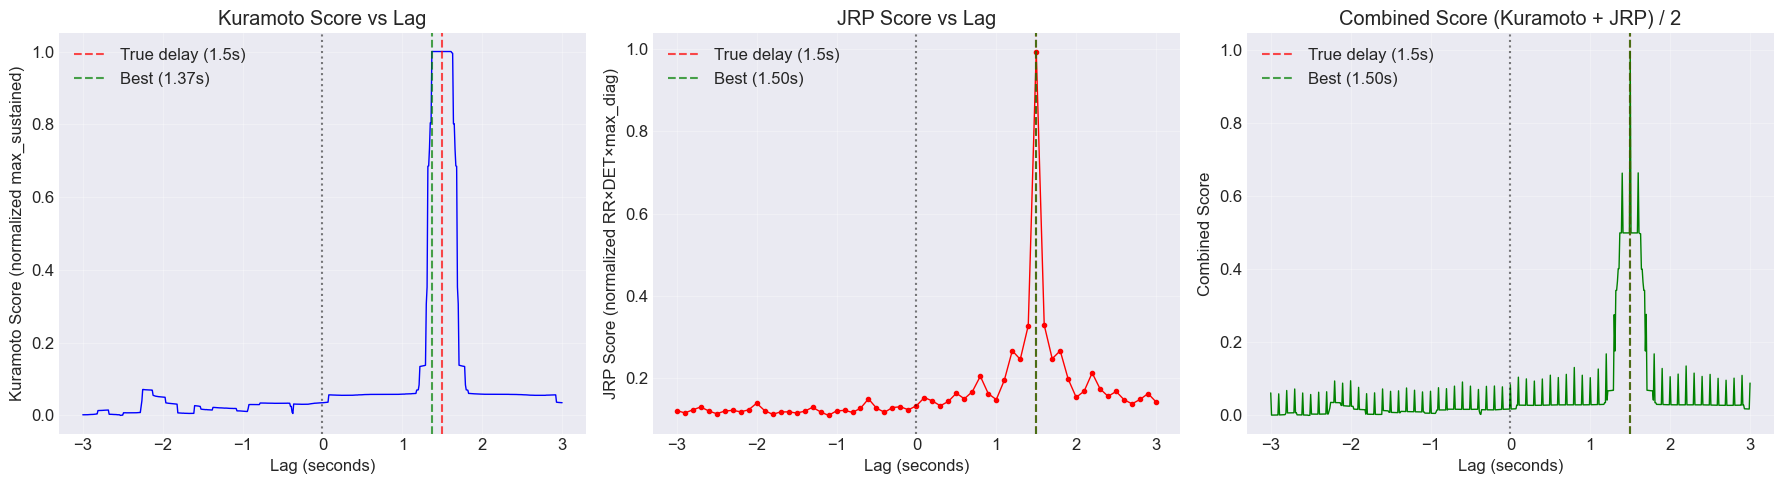

In [5]:
# Combined scores plot
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(results_df['lag_sec'], results_df['kuramoto_score'], 'b-', linewidth=1)
axes[0].set_xlabel('Lag (seconds)')
axes[0].set_ylabel('Kuramoto Score (normalized max_sustained)')
axes[0].set_title('Kuramoto Score vs Lag')
axes[0].grid(True, alpha=0.3)
axes[0].axvline(x=0, color='k', linestyle=':', alpha=0.5)
axes[0].axvline(x=1.5, color='r', linestyle='--', alpha=0.7, label='True delay (1.5s)')
axes[0].axvline(x=best_kuramoto/100, color='g', linestyle='--', alpha=0.7, label=f'Best ({best_kuramoto/100:.2f}s)')
axes[0].legend()

axes[1].plot(jrp_df['lag_sec'], jrp_df['jrp_score'], 'r-o', linewidth=1, markersize=3)
axes[1].set_xlabel('Lag (seconds)')
axes[1].set_ylabel('JRP Score (normalized DET×LAM×RR)')
axes[1].set_title('JRP Score vs Lag')
axes[1].grid(True, alpha=0.3)
axes[1].axvline(x=0, color='k', linestyle=':', alpha=0.5)
axes[1].axvline(x=1.5, color='r', linestyle='--', alpha=0.7, label='True delay (1.5s)')
if best_jrp != 'N/A':
    axes[1].axvline(x=best_jrp/100, color='g', linestyle='--', alpha=0.7, label=f'Best ({best_jrp/100:.2f}s)')
axes[1].legend()

axes[2].plot(results_df['lag_sec'], results_df['combined_score'], 'g-', linewidth=1)
axes[2].set_xlabel('Lag (seconds)')
axes[2].set_ylabel('Combined Score')
axes[2].set_title('Combined Score (Kuramoto + JRP) / 2')
axes[2].grid(True, alpha=0.3)
axes[2].axvline(x=0, color='k', linestyle=':', alpha=0.5)
axes[2].axvline(x=1.5, color='r', linestyle='--', alpha=0.7, label='True delay (1.5s)')
axes[2].axvline(x=best_combined/100, color='g', linestyle='--', alpha=0.7, label=f'Best ({best_combined/100:.2f}s)')
axes[2].legend()

plt.tight_layout()
plt.show()

In [6]:
# Top 10 results
print('=== Top 10 by Kuramoto Score (frac_above_07 × r_mean) ===')
print(results_df.nlargest(10, 'kuramoto_score')[['lag_sec', 'r_mean', 'frac_above_07', 'max_sustained_sec', 'kuramoto_score']].to_string(index=False))

jrp_valid = results_df[(results_df['lag'] != -results_df['lag'].max()) & (results_df['lag'] != results_df['lag'].max()) & (results_df['jrp_RR'] > 0)].copy()
print('\n=== Top 10 by JRP Score (DET × LAM × RR, excl. extreme lags) ===')
print(jrp_valid.nlargest(10, 'jrp_score')[["lag_sec", "jrp_RR", "jrp_DET", "jrp_LAM", "jrp_max_diag", "jrp_score"]].to_string(index=False))

print('\n=== Top 10 by Combined Score ===')
print(results_df.nlargest(10, 'combined_score')[['lag_sec', 'r_mean', 'frac_above_07', 'max_sustained_sec', 'jrp_RR', 'jrp_DET', 'combined_score']].to_string(index=False))

=== Top 10 by Kuramoto Score (Longest Continuous Sync Segment) ===
 lag_sec   r_mean  frac_above_07  max_sustained_sec  kuramoto_score
    1.37 0.963478            1.0              50.01             1.0
    1.38 0.968415            1.0              50.01             1.0
    1.39 0.973078            1.0              50.01             1.0
    1.40 0.977444            1.0              50.01             1.0
    1.41 0.981492            1.0              50.01             1.0
    1.42 0.985197            1.0              50.01             1.0
    1.43 0.988537            1.0              50.01             1.0
    1.44 0.991488            1.0              50.01             1.0
    1.45 0.994029            1.0              50.01             1.0
    1.46 0.996140            1.0              50.01             1.0

=== Top 10 by JRP Score (where computed) ===
 lag_sec   jrp_RR  jrp_DET  jrp_max_diag  jrp_score
     1.5 0.098993 0.985596          4999   0.994069
     1.6 0.032581 0.991255         